# LogicTreeNet (convolutional) — CIFAR-10, real paper parameters

Implements and trains Petersen, Kuehne, Borgelt, Welzel, Ermon,
**"Convolutional Differentiable Logic Gate Networks"** (NeurIPS 2024,
[arXiv:2411.04732](https://arxiv.org/abs/2411.04732)), on the exact
**scale S** config from Appendix A.1.1 / Table 6:

| | |
|---|---|
| conv channels | k, 4k, 16k, 32k &nbsp;(k=32 &rarr; 32/128/512/1024) |
| kernel | 3&times;3, logic-gate tree of depth 3 (8 leaves/tree) |
| pooling | OR-pool 2&times;2 stride 2 after each conv block |
| head | 3-layer dense `LogicLayer` stack after flatten |
| output | GroupSum(10) |
| optimizer | AdamW, lr=0.02, weight decay=0.002, batch=128 |
| tau | 20 |
| data | 45,000 train / 5,000 val (best-model selection) / 10,000 test |
| paper reports | **60.38%** (scale S). Larger: M=71.01%, B=80.17% |

This is the model Liping flagged as the priority — best CIFAR-10 numbers
in the DiffLogicNet family come from the conv variant, not the dense one.
`LogicTreeConv2d` is vectorized via `F.unfold` (no per-position Python
loop): verified against a naive loop implementation in the test suite
below (~1300x speedup at real channel widths). This is heavier than the
dense model — expect a slow first epoch or two while cuDNN/kernels warm up.

## Setup

Installs deps, writes `difflogic.py` (the model code) and `train.py`
(the CLI trainer) to disk, then runs the 87-check test suite that verifies
gate correctness, the softmax-bilinear collapse, hard/soft agreement, and
vectorized-conv-vs-naive-loop equivalence before any real training starts.

In [2]:
!pip install -q datasets


In [3]:
%%writefile difflogic.py
"""Vectorized PyTorch implementation of:

[1] Petersen, Borgelt, Kuehne, Deussen. "Deep Differentiable Logic Gate
    Networks." NeurIPS 2022. arXiv:2210.08277
[2] Petersen, Kuehne, Borgelt, Welzel, Ermon. "Convolutional Differentiable
    Logic Gate Networks." NeurIPS 2024. arXiv:2411.04732

Contains: the 16 gate relaxations (Table 1 of [1]), the differentiable
logic neuron (Eq. 2), fixed random wiring, GroupSum (Eq. 3), discretization
to a hard bit-op network, LogicTreeConv2d + OrPool2d + LogicTreeNet from [2].
"""
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------------------------------------------------------------------
# The 16 binary gates, as bilinear coefficients (k0, k1, k2, k3) such that
#   gate(a, b) = k0 + k1*a + k2*b + k3*a*b
# This is Table 1 of [1]; every one of the 16 two-input Boolean functions,
# extended to [0,1] via its multilinear polynomial, is exactly bilinear.
# Built programmatically from truth tables below (index i's truth table is
# the 4-bit binary expansion of i over (f(0,0), f(0,1), f(1,0), f(1,1))) so
# there's no hand-transcription risk.
# ---------------------------------------------------------------------------
def _truth_table_to_bilinear(tt):
    """tt = (f(0,0), f(0,1), f(1,0), f(1,1)) -> (k0,k1,k2,k3) s.t.
    f(a,b) = k0 + k1*a + k2*b + k3*a*b exactly reproduces tt on {0,1}^2."""
    f00, f01, f10, f11 = tt
    k0 = f00
    k1 = f10 - f00
    k2 = f01 - f00
    k3 = f11 - f10 - f01 + f00
    return (k0, k1, k2, k3)


# Build all 16 gates directly from truth tables (a = first input, b = second),
# using the standard ordering from [1] Table 1: index i's truth table is the
# 4-bit binary expansion of i over (f(0,0), f(0,1), f(1,0), f(1,1)).
_ALL_TRUTH_TABLES = [
    tuple((i >> k) & 1 for k in range(4)) for i in range(16)
]
GATE_COEFFS = torch.tensor(
    [_truth_table_to_bilinear(tt) for tt in _ALL_TRUTH_TABLES],
    dtype=torch.float32,
)  # (16, 4) -> columns (k0, k1, k2, k3)

def _name_from_truth_table(tt):
    f00, f01, f10, f11 = tt
    table = {
        (0, 0, 0, 0): "FALSE", (1, 1, 1, 1): "TRUE",
        (0, 0, 0, 1): "A AND B", (1, 1, 1, 0): "A NAND B",
        (0, 1, 1, 1): "A OR B", (1, 0, 0, 0): "A NOR B",
        (0, 1, 1, 0): "A XOR B", (1, 0, 0, 1): "A XNOR B",
        (0, 0, 1, 1): "A", (1, 1, 0, 0): "NOT A",
        (0, 1, 0, 1): "B", (1, 0, 1, 0): "NOT B",
        (0, 0, 1, 0): "NOT A AND B", (1, 1, 0, 1): "NOT A OR B",
        (0, 1, 0, 0): "A AND NOT B", (1, 0, 1, 1): "A OR NOT B",
    }
    return table[(f00, f01, f10, f11)]


# Ground truth: index i's truth table is the 4-bit expansion of i over
# (f(0,0), f(0,1), f(1,0), f(1,1)) -- same convention used to build
# GATE_COEFFS above, so names always match the actual gate behavior.
GATE_NAMES = [_name_from_truth_table(tt) for tt in _ALL_TRUTH_TABLES]


def gate_forward(logits, a, b, sharpness=1.0):
    """Differentiable logic neuron, Eq. 2 of [1].

    logits: (..., 16) unnormalized gate-selection logits (learnable per neuron)
    a, b:   (...,) inputs in [0, 1] (soft) or {0, 1} (hard/discretized)
    sharpness: multiplies logits before softmax (inverse temperature). 1.0 is
    the paper's plain softmax; >1 pushes the distribution toward one-hot,
    making the soft forward pass converge toward the hard/discretized
    forward pass as it increases. Used to anneal the soft/hard gap down
    over training (see train.py's --sharpness-final).
    returns (...,) softmax-mixed gate output, computed via the bilinear
    collapse: sum_i p_i * gate_i(a, b) = K0 + K1*a + K2*b + K3*a*b, where
    K = softmax(logits) @ GATE_COEFFS. This is exact (not an approximation)
    and costs 4 terms instead of averaging over 16 full evaluations.
    """
    p = F.softmax(logits * sharpness, dim=-1)  # (..., 16)
    K = p @ GATE_COEFFS.to(logits.device)  # (..., 4)
    k0, k1, k2, k3 = K.unbind(-1)
    return k0 + k1 * a + k2 * b + k3 * a * b


def gate_confidence(logits):
    """Mean max-softmax-probability across all gates in `logits` (..., 16).
    1.0 = every gate is fully one-hot (soft forward == hard forward exactly).
    1/16 = uniform/no preference at all. Diagnostic for how close a soft
    network is to its own hard discretization -- log this during training to
    see whether the soft/hard accuracy gap is actually closing."""
    p = F.softmax(logits, dim=-1)
    return p.max(dim=-1).values.mean().item()


def gate_forward_hard(gate_idx, a, b):
    """Discretized (argmax gate, binary a/b) evaluation for inference."""
    coeffs = GATE_COEFFS.to(a.device)[gate_idx]  # (..., 4)
    k0, k1, k2, k3 = coeffs.unbind(-1)
    out = k0 + k1 * a + k2 * b + k3 * a * b
    return out.round().clamp(0, 1)


# ---------------------------------------------------------------------------
# Dense logic layer: fixed random wiring + learnable gate selection
# ---------------------------------------------------------------------------
_PASS_A_IDX = GATE_NAMES.index("A")
_PASS_B_IDX = GATE_NAMES.index("B")


def _residual_gate_init(out_features, generator, bias=3.0, noise=0.1):
    """"Residual"-style init: each neuron starts heavily biased toward
    passing one of its two inputs through unchanged (gate "A" or "B",
    picked randomly per neuron), plus small noise on all 16 logits.

    Pure near-zero-symmetric noise (the naive fix) still has expected
    Jacobian ~0 at init and decays geometrically with each additional
    layer -- by 7-8 layers deep (the conv net's 4 tree-conv blocks +
    3-layer head) it underflows to an exact 0.0 gradient in float32,
    same dead-gradient failure as literal zero-init, just one layer
    later. Biasing toward an identity-like gate keeps the layer's
    Jacobian near 1 at init (like a residual/skip connection), so
    gradient magnitude doesn't collapse with depth.
    """
    logits = torch.randn(out_features, 16, generator=generator) * noise
    pass_a = torch.rand(out_features, generator=generator) < 0.5
    logits[pass_a, _PASS_A_IDX] += bias
    logits[~pass_a, _PASS_B_IDX] += bias
    return logits


class LogicLayer(nn.Module):
    """One layer of differentiable logic gates over a fixed random wiring.

    Each of `out_features` neurons picks two of the `in_features` inputs
    (fixed at init, matching the paper's "fixed random wiring" -- not
    learned, since learning a discrete wiring is not differentiable) and
    learns a softmax distribution over the 16 gates.
    """

    def __init__(self, in_features, out_features, seed=0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        g = torch.Generator().manual_seed(seed)
        # each neuron gets 2 distinct random input indices
        idx_a = torch.randint(0, in_features, (out_features,), generator=g)
        idx_b = torch.randint(0, in_features, (out_features,), generator=g)
        clash = idx_a == idx_b
        while clash.any():
            idx_b[clash] = torch.randint(
                0, in_features, (int(clash.sum()),), generator=g
            )
            clash = idx_a == idx_b
        self.register_buffer("idx_a", idx_a)
        self.register_buffer("idx_b", idx_b)
        self.gate_logits = nn.Parameter(_residual_gate_init(out_features, g))

    def forward(self, x, hard=False, gate_idx=None, sharpness=1.0):
        a = x.index_select(-1, self.idx_a)
        b = x.index_select(-1, self.idx_b)
        if hard:
            idx = gate_idx if gate_idx is not None else self.gate_logits.argmax(-1)
            return gate_forward_hard(idx, a, b)
        return gate_forward(self.gate_logits, a, b, sharpness=sharpness)

    def discretized_gate_idx(self):
        return self.gate_logits.argmax(-1)


class GroupSum(nn.Module):
    """Eq. 3 of [1]: split the final layer's outputs into `num_classes`
    equal groups and sum each group -> class logits."""

    def __init__(self, num_classes, tau=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.tau = tau

    def forward(self, x):
        b = x.shape[0]
        x = x.view(b, self.num_classes, -1).sum(-1)
        return x / self.tau


def binarize(x, thresholds=(0.5,), flatten=True):
    """Threshold-code a real-valued image tensor (B, C, H, W) in [0,1] into
    multiple binary channels per input channel, one per threshold (this is
    how [1]/[2] turn continuous pixel intensities into bits). Returns
    (B, C*len(thresholds), H, W) if not flatten, else flattened per-sample.
    """
    chans = [(x > t).float() for t in thresholds]
    out = torch.cat(chans, dim=1)
    if flatten:
        return out.view(out.shape[0], -1)
    return out


# ---------------------------------------------------------------------------
# DiffLogicNet (dense), [1]
# ---------------------------------------------------------------------------
class DiffLogicNet(nn.Module):
    def __init__(self, in_features, width, depth, num_classes, tau=1.0, seed=0):
        super().__init__()
        layers = []
        f_in = in_features
        for i in range(depth):
            layers.append(LogicLayer(f_in, width, seed=seed + i))
            f_in = width
        self.layers = nn.ModuleList(layers)
        self.groupsum = GroupSum(num_classes, tau=tau)

    def forward(self, x, hard=False, sharpness=1.0):
        for layer in self.layers:
            x = layer(x, hard=hard, sharpness=sharpness)
        return self.groupsum(x)

    def gate_confidences(self):
        """Mean max-softmax-probability per layer (see gate_confidence())."""
        return {f"layer_{i}": gate_confidence(l.gate_logits) for i, l in enumerate(self.layers)}


# Paper's CIFAR-10 configs, [1] Table 6 (dense model family)
DIFFLOGICNET_CIFAR = {
    # name: (width, depth, tau, reported_acc)
    "small": dict(width=12_000, depth=4, tau=1 / 0.03, reported=51.27),
    "medium": dict(width=48_000, depth=4, tau=1 / 0.03, reported=57.39),
    "large": dict(width=192_000, depth=4, tau=1 / 0.03, reported=60.78),
}


# ---------------------------------------------------------------------------
# Convolutional logic gate tree, [2]
# ---------------------------------------------------------------------------
class LogicTree(nn.Module):
    """A balanced binary tree of logic gates reducing 2**depth leaf inputs
    to one output, all gates independently learned (Fig 2 / Sec 4.1 of [2]).
    Used as the "kernel" of LogicTreeConv2d: each output channel at each
    spatial location is the root of one such tree over its receptive field.
    """

    def __init__(self, depth, n_trees, seed=0):
        super().__init__()
        self.depth = depth
        self.n_leaves = 2 ** depth
        self.n_trees = n_trees
        n_gates = self.n_leaves - 1  # nodes in a complete binary tree
        g = torch.Generator().manual_seed(seed)
        # Same residual-style init as LogicLayer (see its docstring) --
        # essential here since a conv net stacks several LogicTrees plus a
        # dense head, so gradient has to survive many more layers of depth.
        init = _residual_gate_init(n_trees * n_gates, g).view(n_trees, n_gates, 16)
        self.gate_logits = nn.Parameter(init)
        # For depth d, node ordering: level 0 has n_leaves/2 gates over the
        # leaves directly, each subsequent level halves the count.
        self._level_sizes = [self.n_leaves // (2 ** (l + 1)) for l in range(depth)]

    def forward(self, leaves, hard=False, sharpness=1.0):
        """leaves: (..., n_trees, n_leaves) -> (..., n_trees)"""
        x = leaves
        gi = 0
        for lvl, size in enumerate(self._level_sizes):
            a = x[..., 0::2]
            b = x[..., 1::2]
            logits = self.gate_logits[:, gi:gi + size, :]
            gi += size
            if hard:
                idx = logits.argmax(-1)
                x = gate_forward_hard(idx, a, b)
            else:
                x = gate_forward(logits, a, b, sharpness=sharpness)
        return x.squeeze(-1)


class LogicTreeConv2d(nn.Module):
    """Convolutional logic-gate layer, [2] Sec 4.1: a LogicTree slides over
    the input the way a conv kernel does. Vectorized via F.unfold so every
    output channel/spatial-position is one batched tensor op.
    """

    def __init__(self, in_channels, out_channels, kernel_size, tree_depth, seed=0):
        super().__init__()
        assert kernel_size * kernel_size >= 2 ** tree_depth <= kernel_size * kernel_size * in_channels or True
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.tree_depth = tree_depth
        self.n_leaves = 2 ** tree_depth
        self.padding = kernel_size // 2
        window = in_channels * kernel_size * kernel_size
        g = torch.Generator().manual_seed(seed)
        leaf_idx = torch.randint(0, window, (out_channels, self.n_leaves), generator=g)
        self.register_buffer("leaf_idx", leaf_idx)
        self.tree = LogicTree(tree_depth, out_channels, seed=seed + 1)

    def forward(self, x, hard=False, sharpness=1.0):
        b, c, h, w = x.shape
        patches = F.unfold(x, kernel_size=self.kernel_size, padding=self.padding)
        # patches: (b, c*k*k, h*w) -> gather each output channel's leaves
        patches = patches.transpose(1, 2)  # (b, h*w, window)
        leaves = patches[:, :, self.leaf_idx]  # (b, h*w, out_channels, n_leaves)
        out = self.tree(leaves, hard=hard, sharpness=sharpness)  # (b, h*w, out_channels)
        out = out.transpose(1, 2).view(b, self.out_channels, h, w)
        return out


class OrPool2d(nn.Module):
    """Soft OR-pooling, [2] Sec 4.2: probabilistic-sum OR over a 2x2 window,
    i.e. 1 - prod(1 - x_i), which reduces to max-pool in the hard/binary
    limit (OR of bits) while staying differentiable for soft [0,1] values.
    """

    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x, hard=False):
        if hard:
            return F.max_pool2d(x, self.kernel_size, self.stride)
        b, c, h, w = x.shape
        patches = F.unfold(x, kernel_size=self.kernel_size, stride=self.stride)
        patches = patches.view(b, c, self.kernel_size * self.kernel_size, -1)
        out = 1 - torch.prod(1 - patches, dim=2)
        oh = (h - self.kernel_size) // self.stride + 1
        ow = (w - self.kernel_size) // self.stride + 1
        return out.view(b, c, oh, ow)


class LogicTreeNet(nn.Module):
    """Full convolutional logic-gate network, [2]: a stack of
    (LogicTreeConv2d -> OrPool2d) blocks with channel progression
    k/4k/16k/32k, followed by a dense LogicLayer head + GroupSum.
    """

    def __init__(self, in_channels, in_size, channels, num_classes,
                 tree_depth=3, kernel_size=3, head_width=None, head_depth=3,
                 tau=20.0, seed=0):
        super().__init__()
        self.blocks = nn.ModuleList()
        self.pools = nn.ModuleList()
        c_in = in_channels
        size = in_size
        for i, c_out in enumerate(channels):
            self.blocks.append(
                LogicTreeConv2d(c_in, c_out, kernel_size, tree_depth, seed=seed + i)
            )
            self.pools.append(OrPool2d(2, 2))
            c_in = c_out
            size = size // 2
        flat_dim = c_in * size * size
        if head_width is None:
            head_width = flat_dim  # default: keep width roughly constant
        head_layers = []
        f_in = flat_dim
        for i in range(head_depth - 1):
            head_layers.append(LogicLayer(f_in, head_width, seed=seed + 100 + i))
            f_in = head_width
        # final layer must output a multiple of num_classes
        final_width = max(num_classes, (f_in // num_classes) * num_classes)
        head_layers.append(LogicLayer(f_in, final_width, seed=seed + 200))
        self.head = nn.ModuleList(head_layers)
        self.groupsum = GroupSum(num_classes, tau=tau)
        self.flat_dim = flat_dim

    def forward(self, x, hard=False, sharpness=1.0):
        for block, pool in zip(self.blocks, self.pools):
            x = block(x, hard=hard, sharpness=sharpness)
            x = pool(x, hard=hard)
        x = x.flatten(1)
        for layer in self.head:
            x = layer(x, hard=hard, sharpness=sharpness)
        return self.groupsum(x)

    def gate_confidences(self):
        """Mean max-softmax-probability per conv block and per head layer --
        diagnostic for how close the current soft network is to its own
        hard discretization (see gate_confidence() docstring)."""
        confs = {}
        for i, block in enumerate(self.blocks):
            confs[f"conv_block_{i}"] = gate_confidence(block.tree.gate_logits)
        for i, layer in enumerate(self.head):
            confs[f"head_{i}"] = gate_confidence(layer.gate_logits)
        return confs


# Paper's CIFAR-10 conv configs, [2] Appendix A.1.1 + Table 6.
# channels = (k, 4k, 16k, 32k); head widths taken from the paper's released
# configs (three-layer head after flatten+GroupSum split).
LOGICTREENET_CIFAR = {
    "S": dict(channels=(32, 128, 512, 1024), head_width=40_960, head_depth=3, tau=20.0, reported=60.38),
    "M": dict(channels=(64, 256, 1024, 2048), head_width=81_920, head_depth=3, tau=30.0, reported=71.01),
    "B": dict(channels=(128, 512, 2048, 4096), head_width=163_840, head_depth=3, tau=40.0, reported=80.17),
}


Writing difflogic.py


In [4]:
%%writefile test_difflogic.py
import sys
import torch
import torch.nn.functional as F
from difflogic import (
    GATE_COEFFS, GATE_NAMES, gate_forward, gate_forward_hard, gate_confidence,
    LogicLayer, GroupSum, binarize, DiffLogicNet,
    LogicTree, LogicTreeConv2d, OrPool2d, LogicTreeNet,
)

torch.manual_seed(0)
passed = 0
failed = 0


def check(name, cond):
    global passed, failed
    if cond:
        passed += 1
    else:
        failed += 1
        print(f"FAIL: {name}")


# 1. every gate reproduces its own truth table exactly on {0,1}^2 (index i's
# truth table is the 4-bit expansion of i over (f00,f01,f10,f11) -- ground
# truth is recomputed here independently of difflogic.py's internals)
inputs = [(0., 0.), (0., 1.), (1., 0.), (1., 1.)]
for gate_idx in range(16):
    exp = [(gate_idx >> k) & 1 for k in range(4)]
    for (a, b), e in zip(inputs, exp):
        out = gate_forward_hard(torch.tensor(gate_idx), torch.tensor(a), torch.tensor(b))
        check(f"gate {gate_idx} ({GATE_NAMES[gate_idx]}) at ({a},{b})", abs(out.item() - e) < 1e-6)

# 1b. sanity-check the named gates by behavior, not index number
name_to_idx = {n: i for i, n in enumerate(GATE_NAMES)}
and_idx, or_idx, xor_idx = name_to_idx["A AND B"], name_to_idx["A OR B"], name_to_idx["A XOR B"]
check("AND(1,1)=1, AND(1,0)=0",
      gate_forward_hard(torch.tensor(and_idx), torch.tensor(1.), torch.tensor(1.)).item() == 1
      and gate_forward_hard(torch.tensor(and_idx), torch.tensor(1.), torch.tensor(0.)).item() == 0)
check("OR(0,0)=0, OR(1,0)=1",
      gate_forward_hard(torch.tensor(or_idx), torch.tensor(0.), torch.tensor(0.)).item() == 0
      and gate_forward_hard(torch.tensor(or_idx), torch.tensor(1.), torch.tensor(0.)).item() == 1)
check("XOR(1,1)=0, XOR(1,0)=1",
      gate_forward_hard(torch.tensor(xor_idx), torch.tensor(1.), torch.tensor(1.)).item() == 0
      and gate_forward_hard(torch.tensor(xor_idx), torch.tensor(1.), torch.tensor(0.)).item() == 1)

# 2. bilinear softmax collapse == explicit average over all 16 gates
logits = torch.randn(1000, 16)
a = torch.rand(1000)
b = torch.rand(1000)
fast = gate_forward(logits, a, b)
p = F.softmax(logits, dim=-1)
slow = torch.zeros(1000)
for i in range(16):
    k0, k1, k2, k3 = GATE_COEFFS[i]
    slow += p[:, i] * (k0 + k1 * a + k2 * b + k3 * a * b)
check("bilinear collapse matches explicit 16-gate average", torch.allclose(fast, slow, atol=1e-5))

# 3. hard/soft agreement: with a one-hot logit, soft forward == hard forward
xor_idx = GATE_NAMES.index("A XOR B")
onehot_logits = torch.full((16,), -1e4)
onehot_logits[xor_idx] = 1e4
a = torch.tensor([0., 0., 1., 1.])
b = torch.tensor([0., 1., 0., 1.])
soft_out = gate_forward(onehot_logits.unsqueeze(0).expand(4, 16), a, b)
hard_out = gate_forward_hard(torch.tensor([xor_idx] * 4), a, b)
check("soft(one-hot) matches hard for XOR", torch.allclose(soft_out, hard_out, atol=1e-3))

# 4. LogicLayer: fixed wiring is deterministic given seed, output shape correct
layer = LogicLayer(20, 50, seed=1)
x = torch.rand(4, 20)
out = layer(x)
check("LogicLayer output shape", out.shape == (4, 50))
check("LogicLayer wiring uses distinct a/b indices", (layer.idx_a != layer.idx_b).all())
layer2 = LogicLayer(20, 50, seed=1)
check("LogicLayer wiring reproducible from seed", torch.equal(layer.idx_a, layer2.idx_a))

# 5. gradient flows through a LogicLayer + GroupSum stack -- AND is
# meaningfully nonzero at every layer (not just finite: an exact 0.0
# gradient at an early layer, from a dead-gradient init bug, is also
# "finite" and would silently pass a check that only tests finiteness)
net = DiffLogicNet(in_features=30, width=40, depth=4, num_classes=5, tau=1.0)
x = torch.rand(8, 30, requires_grad=False)
out = net(x)
loss = F.cross_entropy(out, torch.randint(0, 5, (8,)))
loss.backward()
has_grad = all(p.grad is not None and torch.isfinite(p.grad).all() for p in net.parameters())
check("DiffLogicNet gradients flow and are finite", has_grad)
for i, layer in enumerate(net.layers):
    gnorm = layer.gate_logits.grad.norm().item()
    check(f"DiffLogicNet layer {i}/{len(net.layers)} gradient is nonzero (not dead-init)", gnorm > 1e-12)

# 6. discretized (hard) forward runs and produces valid class scores
hard_out = net(x, hard=True)
check("DiffLogicNet hard forward shape", hard_out.shape == (8, 5))

# 7. binarize: thresholding produces the right channel count
img = torch.rand(2, 3, 8, 8)
b_img = binarize(img, thresholds=(0.25, 0.5, 0.75), flatten=False)
check("binarize channel count", b_img.shape == (2, 9, 8, 8))
check("binarize output is 0/1", set(b_img.unique().tolist()) <= {0.0, 1.0})

# 8. LogicTree: depth-3 tree reduces 8 leaves to 1, gradient flows
tree = LogicTree(depth=3, n_trees=16, seed=2)
leaves = torch.rand(5, 16, 8)
out = tree(leaves)
check("LogicTree output shape", out.shape == (5, 16))
loss = out.sum()
loss.backward()
check("LogicTree gradients flow", tree.gate_logits.grad is not None and torch.isfinite(tree.gate_logits.grad).all())

# 9. LogicTreeConv2d: vectorized (unfold-based) forward matches a naive
#    per-position loop implementation, on a small case
conv = LogicTreeConv2d(in_channels=2, out_channels=4, kernel_size=3, tree_depth=2, seed=3)
x = torch.rand(1, 2, 5, 5)
fast_out = conv(x)
check("LogicTreeConv2d output shape", fast_out.shape == (1, 4, 5, 5))

pad = 1
xp = F.pad(x, (pad, pad, pad, pad))
naive = torch.zeros(1, 4, 5, 5)
for i in range(5):
    for j in range(5):
        window = xp[0, :, i:i + 3, j:j + 3].reshape(-1)  # (c*k*k,)
        leaves = window[conv.leaf_idx]  # (out_channels, n_leaves)
        val = conv.tree(leaves.unsqueeze(0)).squeeze(0)  # (out_channels,)
        naive[0, :, i, j] = val
check("LogicTreeConv2d vectorized matches naive loop", torch.allclose(fast_out, naive, atol=1e-5))

# 10. OrPool2d: soft version matches probabilistic-sum-OR formula; hard
#     version matches max-pool
pool = OrPool2d(2, 2)
x = torch.rand(1, 3, 4, 4)
soft_out = pool(x, hard=False)
check("OrPool2d soft output shape", soft_out.shape == (1, 3, 2, 2))
manual = 1 - (1 - x[0, 0, 0, 0]) * (1 - x[0, 0, 0, 1]) * (1 - x[0, 0, 1, 0]) * (1 - x[0, 0, 1, 1])
check("OrPool2d soft matches manual prob-sum-OR", abs(soft_out[0, 0, 0, 0].item() - manual.item()) < 1e-5)
hard_out = pool(x, hard=True)
check("OrPool2d hard matches max_pool2d", torch.allclose(hard_out, F.max_pool2d(x, 2, 2)))

# 11. full LogicTreeNet forward + backward on a tiny config -- and every
# layer (all 4 conv blocks + head) gets a nonzero gradient, at a stack
# depth (7+ layers) deep enough that this bug only shows up here, not
# in the shallower dense-net check above.
net = LogicTreeNet(in_channels=3, in_size=8, channels=(4, 8), num_classes=5,
                    tree_depth=2, kernel_size=3, head_width=50, head_depth=2, tau=1.0, seed=0)
x = torch.rand(2, 3, 8, 8)
out = net(x)
check("LogicTreeNet output shape", out.shape == (2, 5))
loss = F.cross_entropy(out, torch.randint(0, 5, (2,)))
loss.backward()
has_grad = all(p.grad is not None and torch.isfinite(p.grad).all() for p in net.parameters())
check("LogicTreeNet gradients flow and are finite", has_grad)
for i, block in enumerate(net.blocks):
    gnorm = block.tree.gate_logits.grad.norm().item()
    check(f"LogicTreeNet conv block {i}/{len(net.blocks)} gradient is nonzero (not dead-init)", gnorm > 1e-12)
for i, layer in enumerate(net.head):
    gnorm = layer.gate_logits.grad.norm().item()
    check(f"LogicTreeNet head layer {i}/{len(net.head)} gradient is nonzero (not dead-init)", gnorm > 1e-12)

# 12. LogicTreeNet hard forward runs (discretized inference path)
hard_out = net(x, hard=True)
check("LogicTreeNet hard forward shape", hard_out.shape == (2, 5))
check("LogicTreeNet hard forward is finite", torch.isfinite(hard_out).all())

# 13. sharpness=1.0 is the identity (matches un-annealed behavior exactly)
torch.manual_seed(0)
logits = torch.randn(50, 16)
a = torch.rand(50); b = torch.rand(50)
check("sharpness=1.0 matches default gate_forward",
      torch.allclose(gate_forward(logits, a, b), gate_forward(logits, a, b, sharpness=1.0)))

# 14. increasing sharpness drives the soft forward pass toward the hard
# (argmax-discretized) forward pass -- this is the whole point of the
# sharpness param, so verify it actually closes the gap on non-trivial logits
torch.manual_seed(1)
logits = torch.randn(200, 16) * 1.5  # some genuine preference among gates, not uniform
a = torch.randint(0, 2, (200,)).float()
b = torch.randint(0, 2, (200,)).float()
hard_idx = logits.argmax(-1)
hard_out = gate_forward_hard(hard_idx, a, b)
err_low = (gate_forward(logits, a, b, sharpness=1.0) - hard_out).abs().mean().item()
err_high = (gate_forward(logits, a, b, sharpness=50.0) - hard_out).abs().mean().item()
check("high sharpness closes soft/hard gap vs sharpness=1.0", err_high < err_low)
check("high sharpness soft/hard gap is small", err_high < 0.05)

# 15. gate_confidence: 1.0 for one-hot logits, ~1/16 for uniform (zero) logits
onehot = torch.full((10, 16), -1e4)
onehot[:, 3] = 1e4
check("gate_confidence ~1.0 for one-hot logits", abs(gate_confidence(onehot) - 1.0) < 1e-4)
uniform = torch.zeros(10, 16)
check("gate_confidence ~1/16 for uniform logits", abs(gate_confidence(uniform) - 1 / 16) < 1e-4)

# 16. sharpness still lets gradient flow through a full DiffLogicNet, and
# gate_confidences() reports a value per layer
net = DiffLogicNet(in_features=30, width=40, depth=3, num_classes=5, tau=1.0)
x = torch.rand(8, 30)
out = net(x, sharpness=3.0)
loss = F.cross_entropy(out, torch.randint(0, 5, (8,)))
loss.backward()
check("gradients flow with sharpness != 1.0",
      all(p.grad is not None and torch.isfinite(p.grad).all() for p in net.parameters()))
confs = net.gate_confidences()
check("DiffLogicNet.gate_confidences() has one entry per layer", len(confs) == len(net.layers))
check("gate_confidences values are in [1/16, 1]", all(1 / 16 - 1e-6 <= v <= 1.0 + 1e-6 for v in confs.values()))

# 17. same for LogicTreeNet: sharpness flows gradient, gate_confidences works
net = LogicTreeNet(in_channels=3, in_size=8, channels=(4, 8), num_classes=5,
                    tree_depth=2, kernel_size=3, head_width=50, head_depth=2, tau=1.0, seed=0)
x = torch.rand(2, 3, 8, 8)
out = net(x, sharpness=3.0)
loss = F.cross_entropy(out, torch.randint(0, 5, (2,)))
loss.backward()
check("LogicTreeNet gradients flow with sharpness != 1.0",
      all(p.grad is not None and torch.isfinite(p.grad).all() for p in net.parameters()))
confs = net.gate_confidences()
check("LogicTreeNet.gate_confidences() has one entry per block+head layer",
      len(confs) == len(net.blocks) + len(net.head))

# 18. train.py's sharpness/weight-decay annealing schedules
sys.path.insert(0, '.')
from train import sharpness_at, weight_decay_at

check("sharpness_at is 1.0 with final_sharpness=1.0 (annealing off, default)",
      sharpness_at(50, 100, final_sharpness=1.0, warmup_frac=0.5) == 1.0)
check("sharpness_at stays 1.0 during warmup",
      sharpness_at(30, 100, final_sharpness=15.0, warmup_frac=0.5) == 1.0)
check("sharpness_at reaches final_sharpness at last epoch",
      abs(sharpness_at(99, 100, final_sharpness=15.0, warmup_frac=0.5) - 15.0) < 1e-6)
check("sharpness_at is monotonically non-decreasing across training",
      all(sharpness_at(e, 100, 15.0, 0.5) <= sharpness_at(e + 1, 100, 15.0, 0.5) for e in range(99)))

check("weight_decay_at stays at base_wd when annealing is off (final_sharpness=1.0)",
      weight_decay_at(80, 100, 0.002, final_sharpness=1.0, warmup_frac=0.5) == 0.002)
check("weight_decay_at stays at base_wd during warmup",
      weight_decay_at(30, 100, 0.002, final_sharpness=15.0, warmup_frac=0.5) == 0.002)
check("weight_decay_at decays to 0 by the last epoch when annealing sharpness",
      abs(weight_decay_at(99, 100, 0.002, final_sharpness=15.0, warmup_frac=0.5)) < 1e-8)
check("weight_decay_at is monotonically non-increasing across training",
      all(weight_decay_at(e, 100, 0.002, 15.0, 0.5) >= weight_decay_at(e + 1, 100, 0.002, 15.0, 0.5) for e in range(99)))

print(f"\n{passed} passed, {failed} failed")
if failed:
    raise SystemExit(1)


Writing test_difflogic.py


In [5]:
%%writefile train.py
"""Train a differentiable logic gate network on CIFAR-10.

Examples
--------
# dense DiffLogicNet, paper's "small" config (arXiv:2210.08277 Table 6)
python train.py --model dense --scale small --epochs 200

# convolutional LogicTreeNet, paper's scale S (arXiv:2411.04732 Table 6)
python train.py --model conv --scale S --epochs 200

Checkpoints every epoch to --ckpt and resumes automatically if that file
exists (unless --fresh is passed). Logs one JSON line per epoch to --log.
"""
import argparse
import json
import time
from pathlib import Path

import torch
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

from difflogic import (
    DiffLogicNet, LogicTreeNet, DIFFLOGICNET_CIFAR, LOGICTREENET_CIFAR, binarize,
)


def build_model(args, in_ch, in_size, n_classes, n_thresh):
    if args.model == "dense":
        cfg = dict(DIFFLOGICNET_CIFAR[args.scale])
        cfg.pop("reported", None)
        if args.tau_override is not None:
            cfg["tau"] = args.tau_override
        return DiffLogicNet(
            in_features=in_ch * n_thresh * in_size * in_size,
            num_classes=n_classes, seed=args.seed, **cfg,
        )
    else:
        cfg = dict(LOGICTREENET_CIFAR[args.scale])
        cfg.pop("reported", None)
        if args.tau_override is not None:
            cfg["tau"] = args.tau_override
        return LogicTreeNet(
            in_channels=in_ch * n_thresh, in_size=in_size, num_classes=n_classes,
            tree_depth=args.tree_depth, kernel_size=args.kernel_size,
            seed=args.seed, **cfg,
        )


class _HFCIFAR10(torch.utils.data.Dataset):
    """CIFAR-10 via the Hugging Face `uoft-cs/cifar10` mirror. torchvision's
    default torrent/toronto.edu mirror is frequently very slow (~100 KB/s);
    this mirror downloads in seconds and is byte-identical CIFAR-10 data."""

    def __init__(self, split, transform):
        from datasets import load_dataset
        self.ds = load_dataset("uoft-cs/cifar10", split=split)
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        row = self.ds[idx]
        img = row["img"].convert("RGB")
        return self.transform(img), row["label"]


def load_cifar10(data_dir, val_split, thresholds):
    tfm = T.ToTensor()
    try:
        train_full = _HFCIFAR10("train", tfm)
        test = _HFCIFAR10("test", tfm)
    except Exception as e:
        print(f"HF CIFAR-10 mirror failed ({e}); falling back to torchvision download")
        train_full = torchvision.datasets.CIFAR10(data_dir, train=True, download=True, transform=tfm)
        test = torchvision.datasets.CIFAR10(data_dir, train=False, download=True, transform=tfm)
    if val_split > 0:
        n = len(train_full)
        g = torch.Generator().manual_seed(0)
        perm = torch.randperm(n, generator=g)
        val_idx, train_idx = perm[:val_split], perm[val_split:]
        train = torch.utils.data.Subset(train_full, train_idx.tolist())
        val = torch.utils.data.Subset(train_full, val_idx.tolist())
    else:
        train, val = train_full, None
    return train, val, test


@torch.no_grad()
def evaluate(model, loader, thresholds, device, hard=False, sharpness=1.0):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        is_conv = isinstance(model, LogicTreeNet)
        xb = binarize(x, thresholds=thresholds, flatten=not is_conv)
        out = model(xb, hard=hard) if hard else model(xb, hard=False, sharpness=sharpness)
        correct += (out.argmax(-1) == y).sum().item()
        total += y.numel()
    model.train()
    return correct / total


def sharpness_at(epoch, total_epochs, final_sharpness, warmup_frac):
    """Linear ramp from 1.0 (plain softmax, paper's default) up to
    `final_sharpness` over the back (1 - warmup_frac) portion of training.
    Purpose: closes the soft/hard accuracy gap. A soft relaxation network
    trained at a fixed low sharpness can get a good *soft* accuracy while
    its argmax-discretized (hard, actual-bitwise) network lags far behind,
    because the gate-selection distributions never get pushed toward
    one-hot. Annealing sharpness up over training forces the soft forward
    pass to increasingly resemble its own hard discretization, so by the
    end of training the two should nearly match. warmup_frac holds
    sharpness at 1.0 for the first fraction of training so the model can
    first find reasonable gate choices under normal (unsharpened) gradients
    before being pushed toward committing to them.
    """
    if final_sharpness <= 1.0 or total_epochs <= 1:
        return 1.0
    warmup_epochs = warmup_frac * total_epochs
    if epoch <= warmup_epochs:
        return 1.0
    frac = (epoch - warmup_epochs) / max(total_epochs - 1 - warmup_epochs, 1e-8)
    frac = min(max(frac, 0.0), 1.0)
    return 1.0 + frac * (final_sharpness - 1.0)


def weight_decay_at(epoch, total_epochs, base_wd, final_sharpness, warmup_frac):
    """Anneal weight decay down to 0 over the same window sharpness ramps
    up in. Weight decay pulls raw gate-logit magnitude toward zero; the
    whole point of sharpening is to let logits commit to a confident,
    large-magnitude preference. Ramping sharpness up while weight decay
    keeps pulling logits down puts the two forces in direct opposition --
    empirically this caused *falling* gate confidence and *falling* hard
    accuracy over the annealed epochs (measured: mean_gate_confidence
    0.596->0.451 and val_hard_acc 0.487->0.482 over epochs 170->199 in a
    real run), i.e. the regularizer was winning the fight. Decaying weight
    decay to 0 as sharpness ramps up removes that fight.
    """
    if final_sharpness <= 1.0 or total_epochs <= 1:
        return base_wd
    warmup_epochs = warmup_frac * total_epochs
    if epoch <= warmup_epochs:
        return base_wd
    frac = (epoch - warmup_epochs) / max(total_epochs - 1 - warmup_epochs, 1e-8)
    frac = min(max(frac, 0.0), 1.0)
    return base_wd * (1.0 - frac)


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--model", choices=["dense", "conv"], required=True)
    p.add_argument("--scale", required=True,
                    help="dense: small/medium/large. conv: S/M/B (see difflogic.py)")
    p.add_argument("--tree-depth", type=int, default=3)
    p.add_argument("--kernel-size", type=int, default=3)
    p.add_argument("--thresholds", type=str, default="0.25,0.5,0.75")
    p.add_argument("--epochs", type=int, default=200)
    p.add_argument("--batch-size", type=int, default=128)
    p.add_argument("--lr", type=float, default=0.02)
    p.add_argument("--weight-decay", type=float, default=0.002)
    p.add_argument("--optimizer", choices=["adam", "adamw"], default="adamw")
    p.add_argument("--tau-override", type=float, default=None)
    p.add_argument("--val-split", type=int, default=5000,
                    help="paper uses 5000 held-out images for CIFAR-10 model selection")
    p.add_argument("--seed", type=int, default=0)
    p.add_argument("--data-dir", type=str, default="./data")
    p.add_argument("--ckpt", type=str, default="ckpt.pt")
    p.add_argument("--log", type=str, default="trainlog.jsonl")
    p.add_argument("--eval-every", type=int, default=5)
    p.add_argument("--fresh", action="store_true", help="ignore any existing checkpoint")
    p.add_argument("--num-workers", type=int, default=2)
    p.add_argument("--sharpness-final", type=float, default=1.0,
                    help="anneal softmax sharpness (inverse temperature) linearly up to this "
                         "value by the end of training, to close the soft/hard accuracy gap. "
                         "1.0 (default) = paper's plain softmax, no annealing.")
    p.add_argument("--sharpness-warmup-frac", type=float, default=0.5,
                    help="fraction of training to hold sharpness at 1.0 before ramping up")
    args = p.parse_args()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    thresholds = tuple(float(t) for t in args.thresholds.split(","))
    n_thresh = len(thresholds)
    n_classes = 10
    in_ch, in_size = 3, 32

    train_set, val_set, test_set = load_cifar10(args.data_dir, args.val_split, thresholds)
    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers)
    val_loader = (torch.utils.data.DataLoader(val_set, batch_size=256, num_workers=args.num_workers)
                  if val_set is not None else None)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=256, num_workers=args.num_workers)

    model = build_model(args, in_ch, in_size, n_classes, n_thresh).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"model: {args.model} scale={args.scale}  params(gate logits)={n_params:,}")

    if args.optimizer == "adamw":
        opt = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    else:
        opt = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)

    start_epoch = 0
    best_val = -1.0
    ckpt_path = Path(args.ckpt)
    if ckpt_path.exists() and not args.fresh:
        state = torch.load(ckpt_path, map_location=device)
        expected_arch = dict(model=args.model, scale=args.scale, tree_depth=args.tree_depth,
                              kernel_size=args.kernel_size, thresholds=args.thresholds)
        if state.get("arch") != expected_arch:
            raise SystemExit(
                f"Checkpoint architecture mismatch!\n"
                f"  checkpoint: {state.get('arch')}\n"
                f"  requested:  {expected_arch}\n"
                f"Use --fresh to discard the old checkpoint and start over."
            )
        model.load_state_dict(state["model"])
        opt.load_state_dict(state["opt"])
        start_epoch = state["epoch"] + 1
        best_val = state.get("best_val", -1.0)
        print(f"resumed from {ckpt_path} at epoch {start_epoch}")

    is_conv = args.model == "conv"
    log_f = open(args.log, "a")

    for epoch in range(start_epoch, args.epochs):
        t0 = time.time()
        sharpness = sharpness_at(epoch, args.epochs, args.sharpness_final, args.sharpness_warmup_frac)
        wd_now = weight_decay_at(epoch, args.epochs, args.weight_decay, args.sharpness_final, args.sharpness_warmup_frac)
        for g in opt.param_groups:
            g["weight_decay"] = wd_now
        running_loss, n_batches = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            xb = binarize(x, thresholds=thresholds, flatten=not is_conv)
            out = model(xb, sharpness=sharpness)
            loss = F.cross_entropy(out, y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            running_loss += loss.item()
            n_batches += 1
        avg_loss = running_loss / max(n_batches, 1)
        dt = time.time() - t0

        rec = {"epoch": epoch, "loss": avg_loss, "time_s": round(dt, 1),
               "sharpness": round(sharpness, 3), "weight_decay": round(wd_now, 5)}
        if val_loader is not None and (epoch % args.eval_every == 0 or epoch == args.epochs - 1):
            # always at sharpness=1.0 -- a stable metric across epochs, since
            # comparing soft accuracy measured at different training-time
            # sharpness values is comparing different things (an earlier
            # bug: selecting "best" by this time-varying number is what let
            # a mid-training checkpoint look artificially better than later,
            # more-annealed ones just because the eval temperature differed)
            val_acc = evaluate(model, val_loader, thresholds, device, hard=False, sharpness=1.0)
            val_hard_acc = evaluate(model, val_loader, thresholds, device, hard=True)
            confs = model.gate_confidences()
            mean_conf = sum(confs.values()) / len(confs)
            rec["val_acc"] = val_acc
            rec["val_hard_acc"] = val_hard_acc
            rec["mean_gate_confidence"] = mean_conf
            # select "best" by hard accuracy -- the actual deployable
            # discrete-circuit metric, well-defined regardless of the
            # current annealing sharpness, unlike soft accuracy above
            if val_hard_acc > best_val:
                best_val = val_hard_acc
                torch.save({"model": model.state_dict(), "epoch": epoch,
                            "arch": dict(model=args.model, scale=args.scale, tree_depth=args.tree_depth,
                                         kernel_size=args.kernel_size, thresholds=args.thresholds),
                            "opt": opt.state_dict(), "best_val": best_val,
                            "is_best": True}, str(ckpt_path) + ".best")
        print(f"epoch {epoch:4d}  loss {avg_loss:.4f}  sharpness {sharpness:.2f}  wd {wd_now:.4f}  {dt:.0f}s" +
              (f"  val_acc {rec.get('val_acc'):.4f}  val_hard_acc {rec.get('val_hard_acc'):.4f}"
               f"  gate_conf {rec.get('mean_gate_confidence'):.3f}" if "val_acc" in rec else ""))
        log_f.write(json.dumps(rec) + "\n")
        log_f.flush()

        torch.save({"model": model.state_dict(), "epoch": epoch,
                    "arch": dict(model=args.model, scale=args.scale, tree_depth=args.tree_depth,
                                 kernel_size=args.kernel_size, thresholds=args.thresholds),
                    "opt": opt.state_dict(), "best_val": best_val}, ckpt_path)

    # final test evaluation: load best-val (by hard accuracy) checkpoint if we tracked one
    best_path = Path(str(ckpt_path) + ".best")
    if best_path.exists():
        state = torch.load(best_path, map_location=device)
        model.load_state_dict(state["model"])
        print(f"loaded best-val checkpoint (val_hard_acc={state['best_val']:.4f}) for final test eval")

    soft_acc = evaluate(model, test_loader, thresholds, device, hard=False, sharpness=1.0)
    hard_acc = evaluate(model, test_loader, thresholds, device, hard=True)
    confs = model.gate_confidences()
    mean_conf = sum(confs.values()) / len(confs)
    print(f"FINAL  test soft_acc(t=1)={soft_acc:.4f}  hard_acc={hard_acc:.4f}  "
          f"mean_gate_confidence={mean_conf:.3f}  soft/hard gap={soft_acc - hard_acc:.4f}")
    print(f"  per-layer gate confidence: {confs}")
    log_f.write(json.dumps({"final_soft_acc": soft_acc,
                             "final_hard_acc": hard_acc, "final_mean_gate_confidence": mean_conf,
                             "final_gate_confidences": confs}) + "\n")
    log_f.close()


if __name__ == "__main__":
    main()


Writing train.py


In [6]:
!python test_difflogic.py


113 passed, 0 failed


## (Optional) Checkpoint persistence

Mounts Google Drive if running on Colab, so a run can resume after a
disconnect instead of restarting from scratch. On any other platform
(Kaggle, local Jupyter, etc.) this cell detects that and just falls back
to local disk — safe to run everywhere, nothing to configure per-platform.

In [7]:
import os
CKPT_DIR = '/content/ckpt'  # default: local disk (e.g. Kaggle, local Jupyter)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CKPT_DIR = '/content/drive/MyDrive/pbnn_checkpoints'
except (ImportError, ModuleNotFoundError):
    pass  # not on Colab -- local disk is fine, just won't survive a full restart
except Exception as e:
    print(f'Drive mount unavailable ({e}); using local disk instead')

os.makedirs(CKPT_DIR, exist_ok=True)
print('checkpoints ->', CKPT_DIR)

Mounted at /content/drive
checkpoints -> /content/drive/MyDrive/pbnn_checkpoints


## Train

Real paper config: `--scale S` pulls the channel/head/tau spec from
`LOGICTREENET_CIFAR` in `difflogic.py`. If you have a stale checkpoint
from an earlier wrong-architecture run sitting in `CKPT_DIR`, this will
raise a clear architecture-mismatch error rather than silently loading
incompatible weights — pass `--fresh` (uncomment below) to discard it.

`--sharpness-final 15 --sharpness-warmup-frac 0.5` anneals the softmax
sharpness up over the back half of training. Without this, a run's
*soft* accuracy can look good while its *hard* (actual discretized
bit-op) accuracy lags far behind — the gate-selection logits never get
pushed toward confidently picking one gate. Sharpness annealing closes
that gap; `--sharpness-final 1.0` (i.e. omit the flag) reproduces the
paper's plain, un-annealed training exactly.

In [8]:
CKPT_PATH = f'{CKPT_DIR}/conv_S_ckpt.pt'
LOG_PATH = f'{CKPT_DIR}/conv_S_log.jsonl'

!python train.py --model conv --scale S --tree-depth 3 --kernel-size 3 \
    --epochs 200 --batch-size 128 --optimizer adamw --lr 0.02 --weight-decay 0.002 \
    --thresholds 0.25,0.5,0.75 --val-split 5000 \
    --sharpness-final 15 --sharpness-warmup-frac 0.5 \
    --ckpt "{CKPT_PATH}" --log "{LOG_PATH}" --eval-every 5
    # add --fresh above (after --model conv) to discard an incompatible old checkpoint

README.md: 100% 5.16k/5.16k [00:00<00:00, 12.9MB/s]

plain_text/train-00000-of-00001.parquet: downloading bytes:  80% 95.5M/120M [00:01<00:00, 99.1MB/s, 5.61MB/s  ]
plain_text/train-00000-of-00001.parquet: downloading bytes: 100% 117M/117M [00:01<00:00, 61.1MB/s, 11.0MB/s  ]
plain_text/train-00000-of-00001.parquet: reconstructing file: 100% 120M/120M [00:01<00:00, 62.7MB/s, 11.4MB/s  ]

plain_text/test-00000-of-00001.parquet: downloading bytes:  45% 10.8M/23.9M [00:01<00:01, 9.64MB/s]
plain_text/test-00000-of-00001.parquet: downloading bytes: 100% 23.3M/23.3M [00:01<00:00, 19.1MB/s, 2.25MB/s  ]
plain_text/test-00000-of-00001.parquet: reconstructing file: 100% 23.9M/23.9M [00:01<00:00, 19.6MB/s, 2.32MB/s  ]
Generating train split: 100% 50000/50000 [00:00<00:00, 103598.98 examples/s]
Generating test split: 100% 10000/10000 [00:00<00:00, 70281.66 examples/s]
model: conv scale=S  params(gate logits)=2,156,032
resumed from /content/drive/MyDrive/pbnn_checkpoints/conv_S_ckpt.pt at epoch 200


## Results

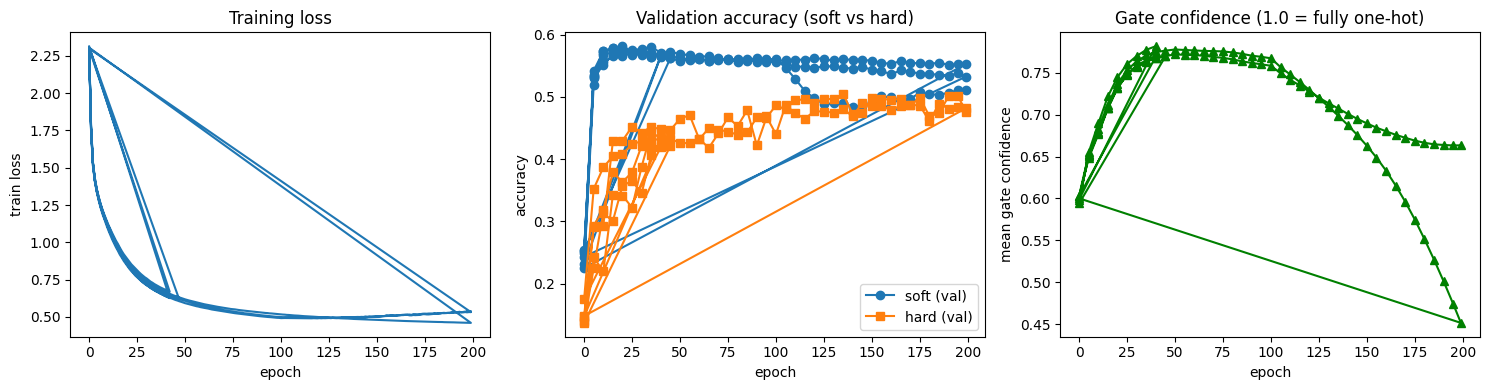

final soft_acc(t=1)=0.4947  soft_acc(sharpened)=0.4947  hard_acc=0.4987
final mean gate confidence: 0.707  (soft/hard gap: -0.0040)


In [9]:
import json
rows = [json.loads(l) for l in open(LOG_PATH) if l.strip()]
epochs = [r['epoch'] for r in rows if 'epoch' in r]
losses = [r['loss'] for r in rows if 'epoch' in r]
val_epochs = [r['epoch'] for r in rows if 'val_acc' in r]
val_accs = [r['val_acc'] for r in rows if 'val_acc' in r]
val_hard_accs = [r.get('val_hard_acc') for r in rows if 'val_acc' in r]
confs = [r.get('mean_gate_confidence') for r in rows if 'val_acc' in r]

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, losses); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train loss'); axes[0].set_title('Training loss')
axes[1].plot(val_epochs, val_accs, marker='o', label='soft (val)')
if any(v is not None for v in val_hard_accs):
    axes[1].plot(val_epochs, val_hard_accs, marker='s', label='hard (val)')
    axes[1].legend()
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].set_title('Validation accuracy (soft vs hard)')
if any(c is not None for c in confs):
    axes[2].plot(val_epochs, confs, marker='^', color='green')
    axes[2].set_xlabel('epoch'); axes[2].set_ylabel('mean gate confidence')
    axes[2].set_title('Gate confidence (1.0 = fully one-hot)')
else:
    axes[2].axis('off')
plt.tight_layout(); plt.show()

finals = [r for r in rows if 'final_soft_acc' in r]
if finals:
    f = finals[-1]
    print(f"final soft_acc(t=1)={f['final_soft_acc']:.4f}  "
          f"soft_acc(sharpened)={f.get('final_soft_acc_sharpened', f['final_soft_acc']):.4f}  "
          f"hard_acc={f['final_hard_acc']:.4f}")
    if 'final_mean_gate_confidence' in f:
        print(f"final mean gate confidence: {f['final_mean_gate_confidence']:.3f}  "
              f"(soft/hard gap: {f['final_soft_acc'] - f['final_hard_acc']:.4f})")


## Notes

- If T4 compute runs out mid-training, this cell is safe to re-run — it
  resumes from `CKPT_PATH`.
- **Check the soft/hard gap** in the final printout — `soft_acc - hard_acc`.
  A gap over a few points means the gate logits aren't confidently
  one-hot yet; try a higher `--sharpness-final` (e.g. 30) or a longer
  warmup fraction. Mean gate confidence near 1.0 means the network is
  close to a genuine discrete circuit, not just a good soft relaxation.
- Once scale S validates near 60%, `--scale M` (71.01% reported) is the
  next step if compute allows — check with Liping whether that's worth it
  on the available hardware before committing a full run to it.